In [8]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import eigh

## Análise de Componentes Principais (PCA)

Considere a matriz de dados **$\mathbf{X}$** com dimensões $N \times D$, em que:

- $N$ = número de amostras
- $D$ = número de variáveis

O objetivo do PCA é transformar **$\mathbf{X}$** em uma nova representação, **$\mathbf{Y}$**, cujas colunas correspondem às componentes principais. A representação passo-a-passo é dada por:

### 1. Centralizar os dados

Primeiro, subtrai-se a média de cada variável de **$\mathbf{X}$**:

$$
\mathbf{X}_c = \mathbf{X} - \bar{\mathbf{X}}
$$

onde $\bar{\mathbf{X}}$ representa o vetor das médias das colunas de **$\mathbf{X}$**.

### 2. Calcular a matriz de covariância

Com os dados centralizados, calcula-se a matriz de covariância:

$$
\mathbf{S}_x = \frac{1}{N-1}\mathbf{X}_c^T \mathbf{X}_c
$$

A matriz **$\mathbf{S}_x$** tem dimensões $D \times D$ e descreve a covariância entre as variáveis.

### 3. Calcular autovalores e autovetores

Em seguida, resolvemos o problema de autovalores e autovetores de **$\mathbf{S}_x$**:

$$
\mathbf{S}_x \mathbf{v}_i = \lambda_i \mathbf{v}_i
$$

- os **autovetores** $\mathbf{v}_i$ definem as direções das componentes principais;
- os **autovalores** $\lambda_i$ indicam quanta variância é explicada em cada direção.

### 4. Ordenar os autovalores e autovetores

Os autovalores são ordenados em ordem decrescente, e os autovetores são reorganizados na mesma ordem.

Assim, as primeiras componentes principais correspondem às direções de maior variância dos dados.

### 5. Construir a matriz de projeção

Selecionando as $k$ componentes principais mais importantes, formamos a matriz:

$$
\mathbf{W} = [\mathbf{v}_1 \ \mathbf{v}_2 \ \dots \ \mathbf{v}_k]
$$

em que **$\mathbf{W}$** tem dimensões $D \times k$.

### 6. Projetar os dados no novo espaço

Os dados centralizados são então projetados no espaço das componentes principais:

$$
\mathbf{Y} = \mathbf{X}_c \mathbf{W}
$$

A matriz **$\mathbf{Y}$** tem dimensões $N \times k$ e representa os dados no novo sistema de coordenadas.

### 7. Reconstrução aproximada dos dados

Se desejado, a matriz de dados original podem ser aproximada:

$$
\mathbf{X}_{aprox} = \mathbf{Y}\mathbf{W}^T + \bar{\mathbf{X}}
$$

Se $k < D$, essa reconstrução será apenas uma aproximação da matriz original.

In [34]:
def centraliza_media(X):
    """
    Input - X: matriz de dados (n_samples, n_features)
    Output - matriz de dados centralizada (n_samples, n_features)
    """

    return X - np.mean(X, axis=0)

def PCA(X, n_components=None):
    """
    Input - X: matriz de dados normalizada (n_samples, n_features)
        - n_components: número de componentes principais a serem retornados
        
    Output - matriz de dados transformada (n_samples, n_components)
    """
    # Centralizando os dados
    X_centered = X - np.mean(X, axis=0)

    # Matriz de covariância
    cov_matrix = np.cov(X_centered, rowvar=False)

    # Autovalores e autovetores
    eigenvalues, eigenvectors = eigh(cov_matrix)

    # Ordenando em ordem decrescente
    sorted_indices = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[sorted_indices]
    eigenvectors = eigenvectors[:, sorted_indices]

    # Selecionando o número de componentes
    if n_components is not None:
        eigenvectors = eigenvectors[:, :n_components]

    # Projeção dos dados
    X_transformed = np.dot(X_centered, eigenvectors)

    return X_transformed,eigenvalues,eigenvectors

def PCA_inversa(X_transformed, eigenvectors):
    """
    Input - X_transformed: matriz de dados transformada (n_samples, n_components)
        - eigenvectors: matriz de autovetores (n_features, n_components)
        
    Output - matriz de dados reconstruída (n_samples, n_features)
    """
    return np.dot(X_transformed, eigenvectors.T)

In [4]:
#Gerando um conjunto de dados sintéticos 2D

x = np.random.normal(scale=2, size=200)
x2 = x+np.random.normal(scale=0.5, size=200)

data = np.array([x,x2]).T

data.shape

(200, 2)

Text(0, 0.5, 'x2')

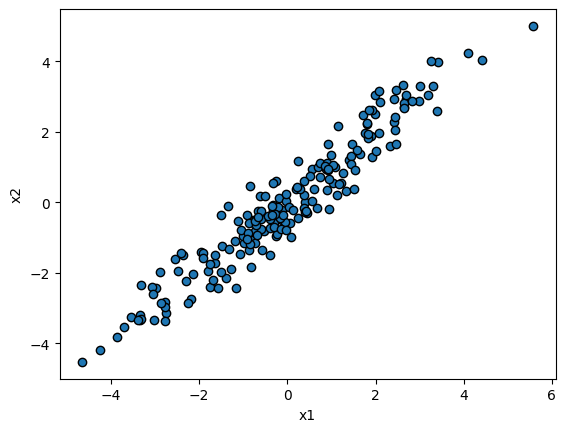

In [28]:
#Plotando o gráfico de dispersão de x1 e x2

fig, ax = plt.subplots()
ax.scatter(data[:,0], data[:,1], edgecolor='black')
ax.set_xlabel('x1')
ax.set_ylabel('x2')

In [ ]:
# Centralizando a matriz de dados na média
X_centered = centraliza_media(data)

# Calculo da matriz de convariância dos dados centralizados
cov_matrix = np.cov(X_centered, rowvar=False)
cov_matrix

array([[3.36774722, 3.2916155 ],
       [3.2916155 , 3.48874948]])

In [ ]:
# Cálculo dos autovalores e autovetores da matriz de covariância
auto_valores, auto_vetores = eigh(cov_matrix)

print("Autovalores:", auto_valores)
print("Autovetores:\n", auto_vetores)

Autovalores: [0.13607688 6.72041982]
Autovetores:
 [[-0.71357455  0.70057931]
 [ 0.70057931  0.71357455]]


In [19]:
# Ordenando os autovalores e autovetores em ordem decrescente

index_sort = np.argsort(auto_valores)[::-1]

auto_valores = auto_valores[index_sort]
auto_vetores = auto_vetores[:, index_sort]

print("Autovalores:", auto_valores)
print("Autovetores:\n", auto_vetores)

Autovalores: [6.72041982 0.13607688]
Autovetores:
 [[ 0.70057931 -0.71357455]
 [ 0.71357455  0.70057931]]


In [20]:
# Projeção dos dados nos autovetores (PCAS)
X_PCA = np.matmul(X_centered, auto_vetores)

X_PCA.shape

(200, 2)

(-7.455221898080493, 8.511342774474114)

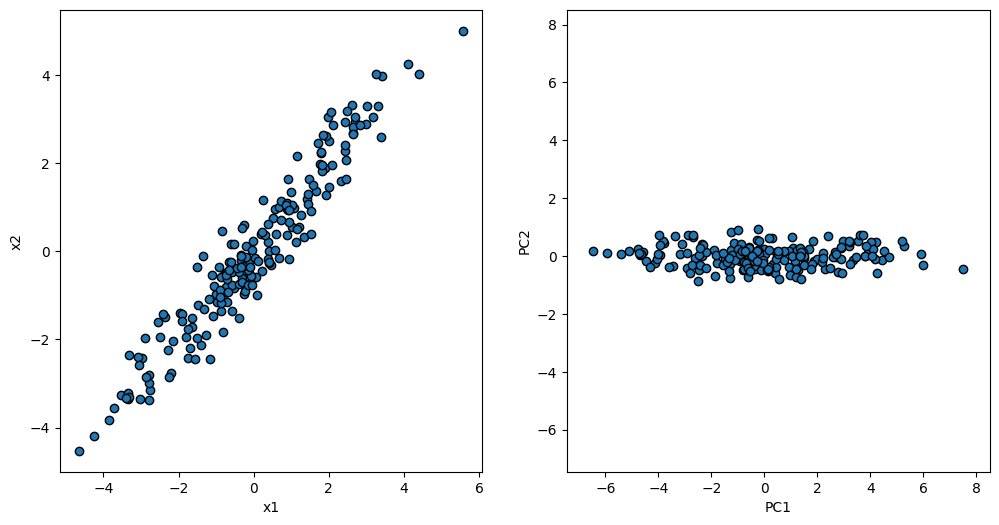

In [27]:
fig, axes = plt.subplots(ncols=2, figsize=(12,6))

axes[0].scatter(data[:,0], data[:,1], edgecolor='black')
axes[0].set_xlabel('x1')
axes[0].set_ylabel('x2')


axes[1].scatter(X_PCA[:,0], X_PCA[:,1], edgecolor='black')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_xlim(X_PCA[:,0].min()-1, X_PCA[:,0].max()+1)
axes[1].set_ylim(X_PCA[:,0].min()-1, X_PCA[:,0].max()+1)


In [32]:
# Transformada inversa dos dados projetados
X_PCA[:,1] = 0
X_reconstructed = np.matmul(X_PCA, auto_vetores.T)

Text(0, 0.5, 'x2')

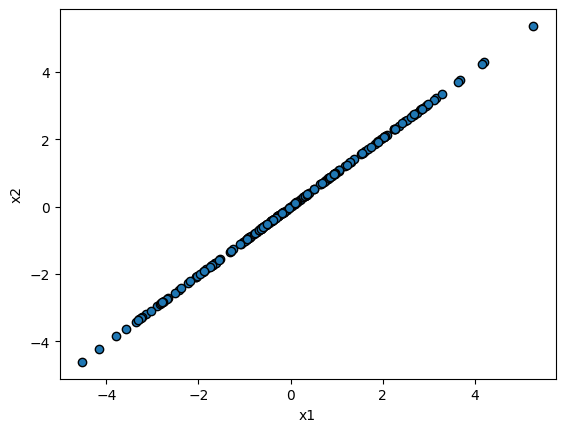

In [33]:
#Plotando os dados reconstruídos
fig,axes = plt.subplots()

axes.scatter(X_reconstructed[:,0], X_reconstructed[:,1], edgecolor='black', label='Dados Reconstruídos')
axes.set_xlabel('x1')
axes.set_ylabel('x2')